# DAS · Zhao vs Mu

[Distributed Acoustic Sensing](https://en.wikipedia.org/wiki/Distributed_acoustic_sensing)
fibers record axial strain-rate along the cable. SWEEP exposes two
different formulations through a unified ``DAS`` facade:

- **Zhao** (Zhao et al., 2026): solves directly for strain-rate components
  ``exx_t``/``ezz_t``; receivers are strain-rate samples.
- **Mu** (velocity-stress-strain): solves the elastic system and reads
  out strain ``exx``/``ezz``; if you ask for ``exx_t``/``ezz_t``, the
  facade takes a finite-difference time derivative for you.

Both should agree on layered isotropic media. The cell that builds each
solver is the only line that changes — pick ``method='zhao'`` or
``method='mu'`` and call it like any other PropTorch.


## 1. Parameters

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import DAS
from sweep.signal import ricker

shape = (96, 200)   # (nz, nx) — small grid keeps the comparison fast
dh    = 10.0        # 10 m spacing
dt    = 0.001       # 1 ms
nt    = 1200        # 1.2 s record
freq  = 10.0        # Ricker dominant frequency (low enough that
                    # the high-frequency tail keeps ~3.5 ppw on the
                    # S-wave at dh=10 m + spatial_order=8)
delay = 0.12
nshots, nrec = 1, 200
src_z, rec_z = 2, 2   # surface acquisition

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 2. Three-layer isotropic elastic model

Layers at 0.25 km and 0.55 km depth; vp ramps 1500 / 2500 / 3000 m/s,
vs = vp / √3, ρ stays at 2100 kg/m³ everywhere. Sources go on top, a
horizontal surface receiver line samples the wavefield.


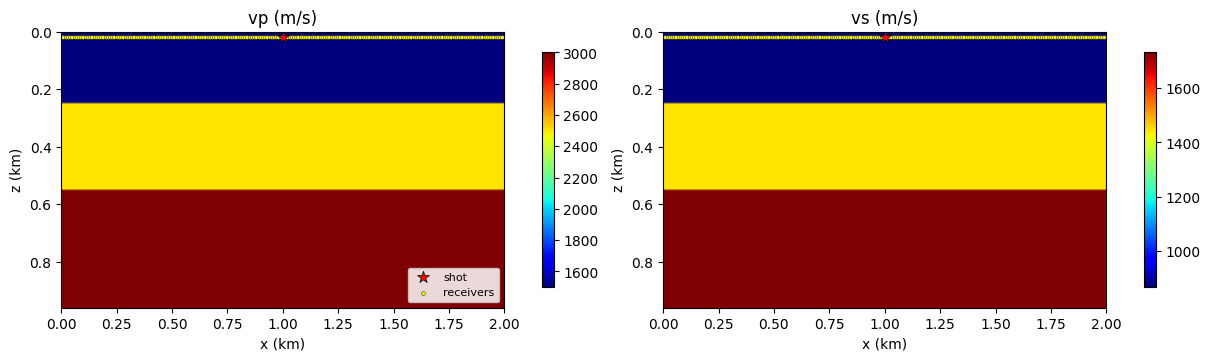

In [2]:
z_idx = np.arange(shape[0], dtype=np.float32)[:, None]
z_m   = z_idx * dh

vp_np = np.where(z_m < 250.0, 1500.0,
         np.where(z_m < 550.0, 2500.0, 3000.0)).astype(np.float32)
vp_np = np.broadcast_to(vp_np, shape).copy()
vs_np = (vp_np / np.sqrt(3.0)).astype(np.float32)
rho_np = np.full(shape, 2100.0, dtype=np.float32)

# Acquisition: 1 shot at x_mid, surface receivers across the full line
src_x = np.array([shape[1] // 2], dtype=np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
src_x_km = src_x * dh / 1000; src_z_km = src_z * dh / 1000
rec_x_km = rec_x * dh / 1000; rec_z_km = rec_z * dh / 1000

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), constrained_layout=True)
for ax, m, name in zip(axes, [vp_np, vs_np], ['vp', 'vs']):
    im = ax.imshow(m, cmap='jet', aspect='auto',
                   extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
    ax.scatter(rec_x_km, np.full_like(rec_x_km, rec_z_km, dtype=float),
               s=8, c='yellow', edgecolors='k', linewidths=0.3)
    ax.scatter(src_x_km, np.full_like(src_x_km, src_z_km, dtype=float),
               s=80, c='red', marker='*', edgecolors='k', linewidths=0.5)
    ax.set_title(f'{name} (m/s)'); ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
    fig.colorbar(im, ax=ax, shrink=0.85)
axes[0].scatter([], [], s=80, c='red', marker='*', edgecolors='k', linewidths=0.5, label='shot')
axes[0].scatter([], [], s=8, c='yellow', edgecolors='k', linewidths=0.3, label='receivers')
axes[0].legend(loc='lower right', fontsize=8, framealpha=0.85)
plt.show()


## 3. Build Zhao and Mu solvers

Both share the same ``shape`` / ``dh`` / ``dt`` / ``nt`` and receive
the same Ricker source. The Zhao solver natively outputs strain-rate
(``exx_t``, ``ezz_t``); we ask the Mu solver for the same fields so
the facade time-differentiates the strain components for direct
comparison.


In [3]:
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)

sources   = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec, rec_z, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)

# spatial_order=8 keeps the dispersion clean at this dh/freq combo:
# with vmin=1500 m/s and Ricker high-freq tail ~37 Hz we have only
# ~4 points per wavelength on dh=10 m, which the default 4th-order
# stencil resolves poorly. Bumping to 8 fixes the grid dispersion.
common = dict(shape=shape, dh=dh, dt=dt, nt=nt, dev=device,
              spatial_order=8,
              receiver_type=['exx_t', 'ezz_t'])
solver_zhao = DAS(method='zhao', **common)
solver_mu   = DAS(method='mu',   **common)
print('zhao impl:', solver_zhao.solver.impl)
print('mu   impl:', solver_mu.solver.impl)


zhao impl: c
mu   impl: c


### Aside · which sources and receivers does this equation accept?

`DASZhao` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
from sweep.equations import DASZhao
eq = DASZhao(device=device)
print('models (input order matters!):')
for spec in eq.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', eq.default_source_fields, '/', eq.default_receiver_fields)
print('receivers :')
for spec in eq.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Elastic P-wave velocity model.
  - vs       [m/s]  — Elastic S-wave velocity model.
  - rho      [kg/m^3]  — Density model.
defaults  : ['sxx', 'szz'] / ['exx_t', 'ezz_t']
receivers :
  - exx_t    aliases=()  — Normal strain-rate in the x direction.
  - ezz_t    aliases=()  — Normal strain-rate in the z direction.
  - sxx      aliases=('stress_xx',)  — Normal stress in the x direction.
  - szz      aliases=('stress_zz',)  — Normal stress in the z direction.
  - das35_t  aliases=()  — 35.3 degree helical-fiber axial strain-rate.
  - das54x_t aliases=()  — 54.7 degree helical-fiber axial strain-rate for x-oriented core.
  - das54z_t aliases=()  — 54.7 degree helical-fiber axial strain-rate for z-oriented core.


## 4. Forward modeling

In [5]:
vp_t  = torch.tensor(vp_np,  device=device)
vs_t  = torch.tensor(vs_np,  device=device)
rho_t = torch.tensor(rho_np, device=device)
models = [vp_t, vs_t, rho_t]

with torch.no_grad():
    rec_zhao = solver_zhao(wavelet, sources, receivers, models=models).detach()
    rec_mu   = solver_mu(wavelet, sources, receivers, models=models).detach()
print('zhao record:', tuple(rec_zhao.shape))
print('mu   record:', tuple(rec_mu.shape))


zhao record: (1, 1200, 200, 2)
mu   record: (1, 1200, 200, 2)


## 5. Strain-rate gather comparison

Top row: Zhao native ``exx_t`` / ``ezz_t``. Bottom row: Mu facade
post-processed to the same components.


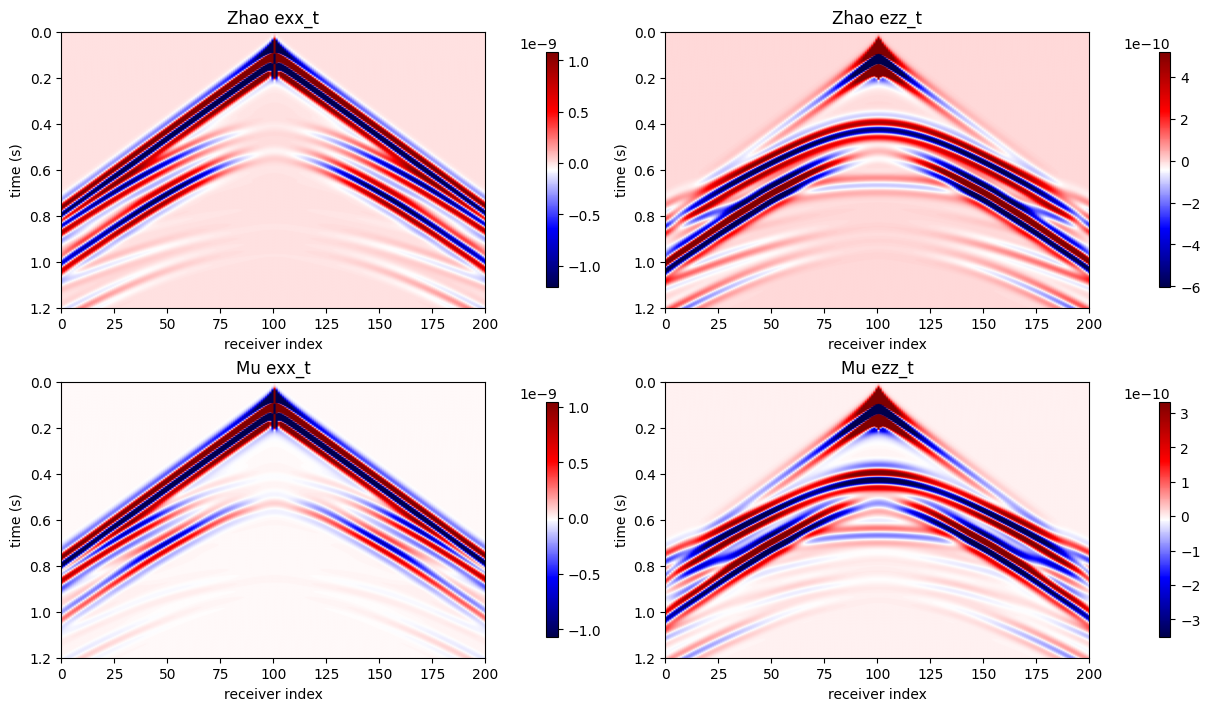

In [6]:
gather_zhao = rec_zhao[0].cpu().numpy()   # (nt, nrec, 2)
gather_mu   = rec_mu[0].cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for row, (gather, method) in enumerate([(gather_zhao, 'Zhao'),
                                          (gather_mu,   'Mu')]):
    for col, name in enumerate(['exx_t', 'ezz_t']):
        g = gather[..., col]
        vmin, vmax = np.percentile(g, [2, 98])
        ax = axes[row, col]
        im = ax.imshow(g, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto',
                       extent=[0, nrec, nt * dt, 0])
        ax.set_xlabel('receiver index'); ax.set_ylabel('time (s)')
        ax.set_title(f'{method} {name}')
        fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()


---

<p><strong>Download this notebook</strong> &mdash; <a href="04_das_zhao_vs_mu.ipynb" download><code>04_das_zhao_vs_mu.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/04_das_zhao_vs_mu.ipynb">view on GitHub</a></p>
